# Investigate the numerical calculation of 

In [1]:
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure, savefig

def nicegrid(ax=plt):
    ax.grid(True, which='major', color='#666666', linestyle=':')
    ax.grid(True, which='minor', color='#999999', linestyle=':', alpha=0.2)
    ax.minorticks_on()

plt.rcParams['figure.figsize'] = [8, 5.0]; plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300; plt.rcParams['lines.linewidth'] = 2
plt.rcParams['axes.xmargin'] = 0; plt.rcParams['axes.grid'] = True
plt.rcParams["figure.autolayout"] = True

import numpy as np
from scipy.interpolate import InterpolatedUnivariateSpline
from scipy.integrate import quad
import pandas as pd 

In [2]:
e = 0.6                             #   % orbit ecc
a = 1.5                              #  % semi-major axis

N = 11 #                               % number of pts
Nc = 6   #                              % number of fourier terms
theta = np.linspace(-np.pi,np.pi,N)  #       % eccentric anomaly - start at -pi for plot convenience

r = a*(1-e**2)/(1- e*np.cos(theta));      # % radius https://en.wikipedia.org/wiki/Eccentric_anomaly

In [3]:
table = []
table.append(theta)
table.append(r)
df = pd.DataFrame(table, index=['theta', 'r'])
df[df.isna()]=0
print(df.T)

       theta         r
0  -3.141593  0.600000
1  -2.513274  0.646286
2  -1.884956  0.809846
3  -1.256637  1.178507
4  -0.628319  1.865564
5   0.000000  2.400000
6   0.628319  1.865564
7   1.256637  1.178507
8   1.884956  0.809846
9   2.513274  0.646286
10  3.141593  0.600000


In [4]:
r_data = r
theta_data = theta
N = len(r_data); print(N)
r = []
theta = []

11


In [5]:
theta_dense = np.linspace(-np.pi,np.pi,100*N)  #  dense eccentric anomaly for integration

r_interp = InterpolatedUnivariateSpline(theta_data, r_data, k=2)

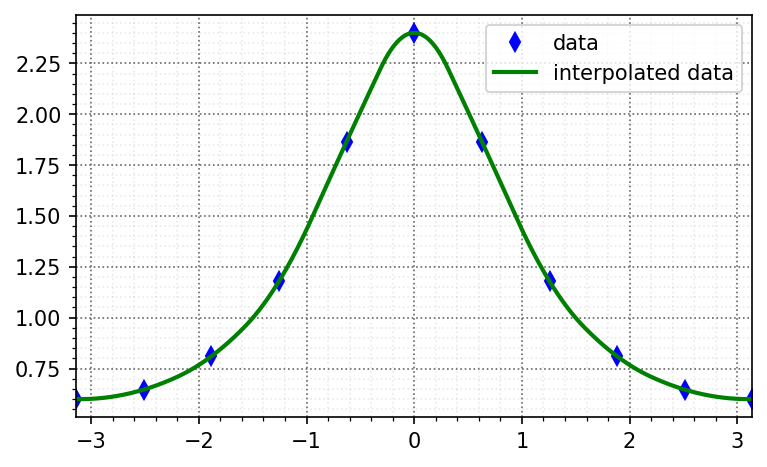

In [6]:
fig = figure(figsize=(5, 3),dpi=150,constrained_layout = True)
plt.plot(theta_data,r_data,'bd',label='data')
plt.plot(theta_dense,r_interp(theta_dense),'g-',lw=2,label='interpolated data')
plt.legend()
nicegrid()
fig.savefig('./figs/HW5_1.png', bbox_inches='tight', dpi=300)
plt.show()

# Analysis
Numerically compute $a_k$ and $b_k$ , where $\displaystyle a_k = \frac{1}{\pi} \int_{-\pi}^{\pi} r(\theta) \cos(k\theta) d\theta$ and 
$\displaystyle b_k = \frac{1}{\pi} \int_{-\pi}^{\pi} r(\theta) \sin(k\theta) d\theta$

In [7]:
def integrand_cos(x, k):
    return r_interp(x)*np.cos(k*x)/np.pi

def integrand_sin(x, k):
    return r_interp(x)*np.sin(k*x)/np.pi

A0 = quad(r_interp, theta_data[0], theta_data[-1])[0]/2/np.pi

A = [A0]
B = [0]
for k in np.arange(1,Nc+1):
    A = np.append(A,quad(integrand_cos, theta_data[0], theta_data[-1], args=(k))[0])
    B = np.append(B,quad(integrand_sin, theta_data[0], theta_data[-1], args=(k))[0])

In [8]:
table = []
table.append(A)
table.append(B)
df = pd.DataFrame(table, index=['A', 'B'])
df[df.isna()]=0
print(df.T)

          A             B
0  1.199920  0.000000e+00
1  0.799906  1.442219e-16
2  0.264032  7.094884e-17
3  0.084828  1.339174e-16
4  0.025881  1.612750e-16
5  0.010273  5.741927e-17
6  0.007736 -6.845065e-18


# Synthesis

In [9]:
r_approx = 0
for k in np.arange(Nc+1):
    r_approx += A[k]*np.cos(k*theta_dense) + B[k]*np.sin(k*theta_dense)

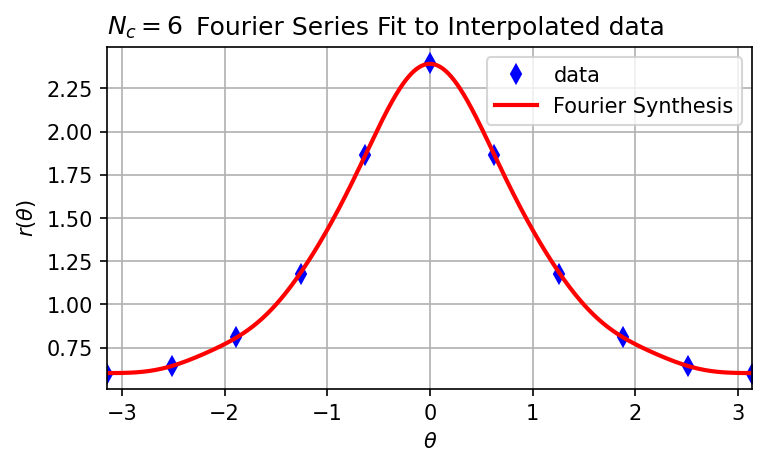

In [10]:
fig = figure(figsize=(5, 3),dpi=150,constrained_layout = True)
plt.plot(theta_data,r_data,'bd',label='data')
plt.plot(theta_dense,r_approx,'r-',label='Fourier Synthesis')
plt.title('Fourier Series Fit to Interpolated data')
plt.title('$N_c=$'+str(Nc),loc='left')
plt.xlabel(r'$\theta$')
plt.ylabel(r'$r(\theta)$')
plt.legend()
fig.savefig('./figs/HW5_2.png', bbox_inches='tight', dpi=300)
plt.show()

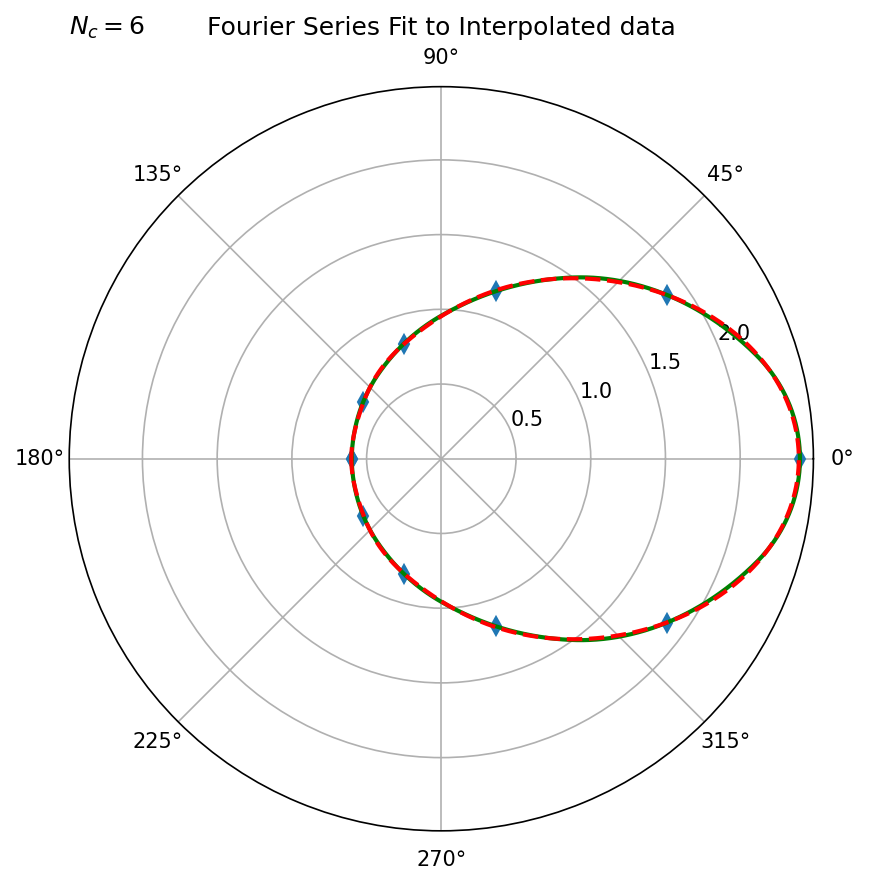

In [11]:
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={'projection': 'polar'})
ax.plot(theta_data, r_data,'d')
ax.plot(theta_dense, r_interp(theta_dense),'g-',lw=2)
ax.plot(theta_dense, r_approx,'r--')
plt.title('Fourier Series Fit to Interpolated data')
plt.title('$N_c=$'+str(Nc),loc='left')
fig.savefig('./figs/HW5_3.png', bbox_inches='tight', dpi=300)
plt.show()

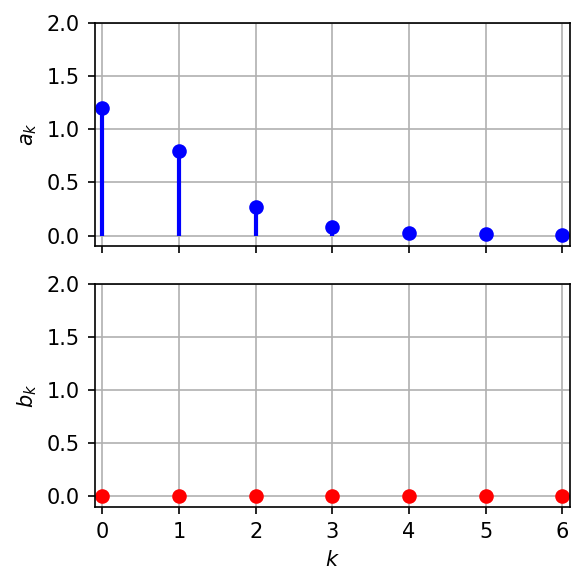

In [12]:
fig = plt.figure(figsize=(4, 4),dpi=150)
ax1 = fig.add_subplot(211)
ax2 = fig.add_subplot(212, sharex=ax1, sharey=ax1)

markerline, stemlines, baseline = ax1.stem(np.arange(Nc+1), A,linefmt='b',markerfmt='bo')
plt.setp(baseline, visible=False)
markerline, stemlines, baseline = ax2.stem(np.arange(Nc+1), B,linefmt='r',markerfmt='ro')
plt.setp(baseline, visible=False)

ax1.set_xlim([-0.1, Nc+0.1])
ax1.set_ylim([-0.1, 2])
ax1.set_ylabel('$a_k$')
ax2.set_ylabel('$b_k$')
ax2.set_xlabel('$k$')

plt.setp(ax1.get_xticklabels(), visible=False)
fig.savefig('./figs/HW5_4.png', bbox_inches='tight', dpi=300)
plt.show()

In [13]:
def fourier_series_err(n):
    A = quad(r_interp, -np.pi, np.pi)[0]/2/np.pi
    B = [0]
    for k in np.arange(1,n+1):
        A = np.append(A,quad(integrand_cos, -np.pi, np.pi, args=(k))[0])
        B = np.append(B,quad(integrand_sin, -np.pi, np.pi, args=(k))[0])

    try:
        r_approx = A[0]*np.ones_like(theta_data)
    except:
        r_approx = A*np.ones_like(theta_data)

    for k in np.arange(1,n+1):
        r_approx += A[k]*np.cos(k*theta_data) + B[k]*np.sin(k*theta_data)

    error = r_data - r_approx
    return np.sqrt(np.dot(error,error))

In [14]:
error = []
KK = np.arange(1,2*Nc)
for kk in KK:
    error = np.append(error,fourier_series_err(kk))

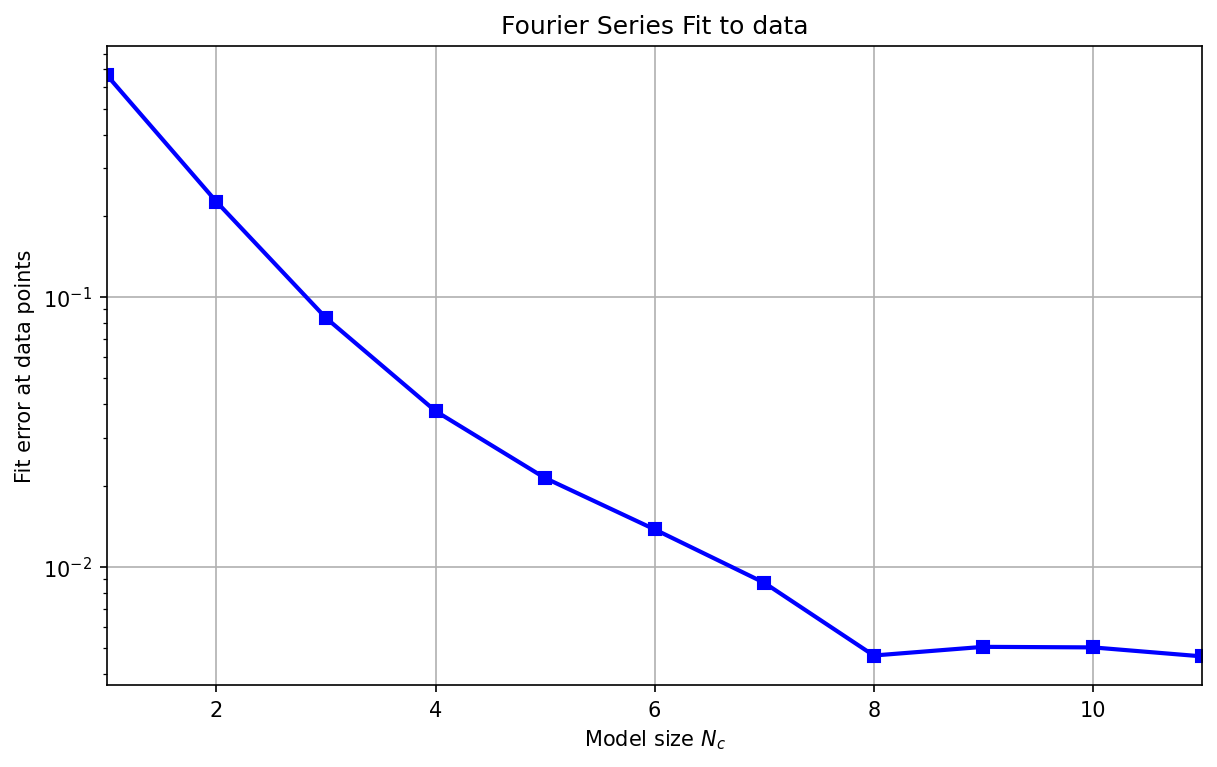

In [15]:
fig = figure(figsize=(8, 5),dpi=150,constrained_layout = True)
plt.semilogy(KK,error,'bs-')
plt.ylabel('Fit error at data points')
plt.xlabel('Model size $N_c$')
plt.title('Fourier Series Fit to data')
fig.savefig('./figs/HW5_5.png', bbox_inches='tight', dpi=300)
plt.show()